<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/06_transfer_learning_for_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning for Images

Training deep Convolutional Neural Networks (CNNs) from scratch requires large datasets, powerful hardware, and significant training time.

Transfer Learning solves this problem by using a model that has already been trained on a massive dataset such as ImageNet. These pre-trained models have already learned useful visual features like edges, textures, shapes, and object parts.

Instead of starting from random weights, we reuse these learned features and add new layers for our specific classification task. This approach reduces training time, requires less data, and often produces better results than training a CNN from scratch.

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

Trainable: False


In [5]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )

])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [8]:
import pandas as pd

comparison = pd.DataFrame({

    "CNN from Scratch":[
        "Random weights",
        "Needs large dataset",
        "Long training time",
        "More computation"
    ],

    "Transfer Learning":[
        "Pre-trained weights",
        "Works well on small datasets",
        "Fast training",
        "Less computation"
    ]

})

comparison

,CNN from Scratch,Transfer Learning
0,Random weights,Pre-trained weights
1,Needs large dataset,Works well on small datasets
2,Long training time,Fast training
3,More computation,Less computation


In [9]:
models = pd.DataFrame({

    "Model":[
        "MobileNetV2",
        "ResNet50",
        "VGG16",
        "EfficientNetB0"
    ],

    "Common Use":[
        "Mobile Applications",
        "Deep Image Classification",
        "Feature Extraction",
        "Efficient Computer Vision"
    ]

})

models

,Model,Common Use
0,MobileNetV2,Mobile Applications
1,ResNet50,Deep Image Classification
2,VGG16,Feature Extraction
3,EfficientNetB0,Efficient Computer Vision


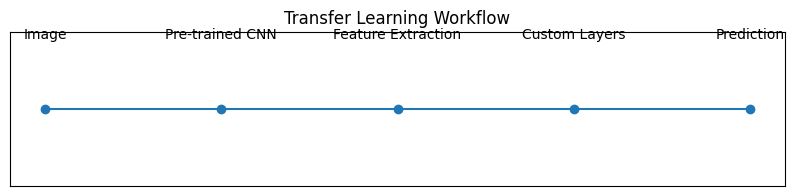

In [10]:
steps = [

    "Image",

    "Pre-trained CNN",

    "Feature Extraction",

    "Custom Layers",

    "Prediction"

]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Transfer Learning Workflow")

plt.show()